## Human in loop


In [12]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [17]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x116e15a90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x116e16490>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [18]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt ## for hil

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [19]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

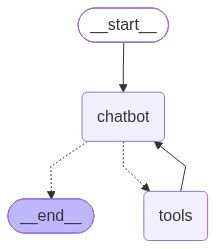

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [21]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_f3d9f6c9-5e13-4cea-8291-e9be7cc585de)
 Call ID: fc_f3d9f6c9-5e13-4cea-8291-e9be7cc585de
  Args:
    query: User needs expert guidance and assistance for building an AI agent. Please provide assistance.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_f3d9f6c9-5e13-4cea-8291-e9be7cc585de)
 Call ID: fc_f3d9f6c9-5e13-4cea-8291-e9be7cc585de
  Args:
    query: User needs expert guidance and assistance for building an AI agent. Please provide assistance.


In [22]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response}) ##command is used to inout the human message

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_f3d9f6c9-5e13-4cea-8291-e9be7cc585de)
 Call ID: fc_f3d9f6c9-5e13-4cea-8291-e9be7cc585de
  Args:
    query: User needs expert guidance and assistance for building an AI agent. Please provide assistance.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely—happy to help you get started building an AI agent! Below is a quick‑start guide that expands on the recommendation you received and points you toward the most useful resources, tools, and best‑practice patterns.

---

## 1️⃣ Choose a Framework: **LangGraph** (highly recommended)

| Why LangGraph? | What it Gives You |